This model will be similar to model 19 which combined the original Model 3 V3 DINOv2 carbohydrate estimator, with the model 18 mass estimator. It had previously shown that giving the actual mass values improved the carbohydrate estimation with Model 3 V3 as the carbohydrate estimator, so this test will see if the slightly stronger Model 24 can improve on that.

Prerequisits

In [ ]:
!pip install -q keras-hub huggingface_hub scikit-learn joblib

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import keras_hub

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.optimizer.set_jit(False)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Paths and settings

In [ ]:
# =========================================================
# MODEL 25
# RDINet RGB-D carb estimator + predicted mass estimator
# Simple late-fusion combiner
#
# Carb model: Model 24 RDINet RGB-D carbohydrate estimator
# Mass model: Model 18 DINOv3 RGB-only mass estimator
# =========================================================

MODEL_NAME = "Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion"

MODEL25_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion"
)
MODEL25_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = MODEL25_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

# Model 24 paths
MODEL24_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor"
)

MODEL24_VERIFIED_DIR = MODEL24_DIR / "verified_prediction_exports"

# Reuse the same prepared CSVs as Model 24/23
MODEL24_PREP_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_23_RDINet_3Level_DINOv2_RGB_DINOv2_depthcolor/prep_files"
)

train_csv = MODEL24_PREP_DIR / "train_model23.csv"
val_csv   = MODEL24_PREP_DIR / "val_model23.csv"
test_csv  = MODEL24_PREP_DIR / "test_model23.csv"

# Model 18 mass estimator
MODEL18_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_18_DINOv3_RGB_only_Mass"
)

MODEL18_WEIGHTS = MODEL18_DIR / "best_model_stage2.weights.h5"
MODEL18_FINAL_MODEL = MODEL18_DIR / "final_model.keras"

# Image / mass model settings
IMG_HEIGHT = 224
IMG_WIDTH = 224
MASS_BACKBONE_PRESET = "dinov3_vit_base_lvd1689m"

MASS_BATCH_SIZE = 16

# Combiner settings
COMBINER_EPOCHS = 500
COMBINER_LR = 1e-3
COMBINER_BATCH_SIZE = 16

print("Model 25 dir:", MODEL25_DIR)
print("Model 24 dir:", MODEL24_DIR)
print("Model 24 verified dir:", MODEL24_VERIFIED_DIR)
print("Model 18 dir:", MODEL18_DIR)

Model 25 dir: /content/drive/MyDrive/Speciale/Models/Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion
Model 24 dir: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor
Model 24 verified dir: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports
Model 18 dir: /content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass


Loading prepared train/val/test metadata

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

for d in [train_df, val_df, test_df]:
    d["dish_id"] = d["dish_id"].astype(str).str.strip()
    d["rgb_path"] = d["rgb_path"].astype(str)
    d["total_carb"] = pd.to_numeric(d["total_carb"], errors="coerce").astype("float32")

    if "depth_path" in d.columns:
        d["depth_path"] = d["depth_path"].astype(str)

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

display(train_df.head())

Train: (2419, 10)
Val:   (334, 10)
Test:  (507, 10)


,dish_id,total_carb,split,source_cafe,rgb_path,depth_path,rgb_exists,depth_exists,rgb_size,depth_size
0,dish_1556572657,2.268,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,412129,128124
1,dish_1556573514,1.219,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,432908,286439
2,dish_1556575014,3.906,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,409854,300120
3,dish_1556575083,5.760,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,396942,288910
4,dish_1556575124,0.952,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,404314,287977


Loading saved model 24 predictions

In [ ]:
def find_model24_prediction_csv(split_name):
    """
    Finds the saved Model 24 prediction CSV for train/val/test.
    It first searches the verified export folder, then the full Model 24 folder.
    """

    search_dirs = []

    if MODEL24_VERIFIED_DIR.exists():
        search_dirs.append(MODEL24_VERIFIED_DIR)

    search_dirs.append(MODEL24_DIR)

    candidates = []

    for search_dir in search_dirs:
        for pattern in [
            f"*{split_name}*.csv",
            f"**/*{split_name}*.csv",
        ]:
            candidates.extend(list(search_dir.glob(pattern)))

    candidates = sorted(set(candidates))

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"No Model 24 prediction CSV found for split '{split_name}'. "
            f"Searched in {search_dirs}"
        )

    print(f"\nCandidate files for {split_name}:")
    for i, p in enumerate(candidates):
        print(i, p)

    preferred_keywords = [
        "verified",
        "rdinet",
        "prediction",
        "predictions",
        "export",
        split_name,
    ]

    bad_keywords = [
        "comparison",
        "summary",
        "metric",
        "model25",
        "model_25",
        "ingredient",
        "mass_fusion",
        "actual_mass",
    ]

    scored = []

    for p in candidates:
        name = p.name.lower()
        score = sum(k in name for k in preferred_keywords)
        score -= 10 * sum(k in name for k in bad_keywords)

        # Prefer files inside verified_prediction_exports if available
        if "verified_prediction_exports" in str(p).lower():
            score += 5

        scored.append((score, p))

    scored = sorted(scored, key=lambda x: x[0], reverse=True)

    chosen = scored[0][1]
    print(f"Chosen {split_name} prediction CSV:", chosen)

    return chosen


def detect_prediction_column(df):
    preferred_cols = [
        "prediction",
        "pred",
        "y_pred",
        "rdinet_carb_pred",
        "model24_pred",
        "final_pred",
        "carb_pred",
        "predicted_carb",
        "carbohydrates_g",
    ]

    for col in preferred_cols:
        if col in df.columns:
            return col

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    pred_like_cols = [
        c for c in numeric_cols
        if "pred" in c.lower() or "prediction" in c.lower()
    ]

    if len(pred_like_cols) > 0:
        return pred_like_cols[0]

    raise ValueError(
        "Could not detect prediction column. Columns found:\n"
        + str(df.columns.tolist())
    )


def load_model24_predictions(split_name):
    csv_path = find_model24_prediction_csv(split_name)
    pred_df = pd.read_csv(csv_path)

    print(f"\nLoaded {split_name} prediction file:")
    print("Shape:", pred_df.shape)
    print("Columns:", pred_df.columns.tolist())

    if "dish_id" not in pred_df.columns:
        raise ValueError(f"'dish_id' missing in {csv_path}")

    pred_col = detect_prediction_column(pred_df)

    out = pred_df[["dish_id", pred_col]].copy()
    out = out.rename(columns={pred_col: "rdinet_carb_pred"})

    out["dish_id"] = out["dish_id"].astype(str).str.strip()
    out["rdinet_carb_pred"] = pd.to_numeric(
        out["rdinet_carb_pred"],
        errors="coerce"
    ).astype("float32")

    if out["rdinet_carb_pred"].isna().sum() > 0:
        raise ValueError(f"NaN values found in RDINet predictions for {split_name}")

    print("Using prediction column:", pred_col)
    display(out.head())

    return out


train_rdinet_pred_df = load_model24_predictions("train")
val_rdinet_pred_df   = load_model24_predictions("val")
test_rdinet_pred_df  = load_model24_predictions("test")


Candidate files for train:
0 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/model25_rdinet_predictions_train.csv
1 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_train_stage_1.csv
2 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_train_stage_2.csv
Chosen train prediction CSV: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_train_stage_1.csv

Loaded train prediction file:
Shape: (2419, 15)
Columns: ['dish_id', 'total_carb', 'split', 'source_cafe', 'rgb_path', 'depth_path', 'rgb_exists', 'depth_exists', 'rgb_size', 'depth_size', 'rdinet_carb_pred', 'rdinet_abs_error', 'rdinet_

,dish_id,rdinet_carb_pred
0,dish_1556572657,1.589515
1,dish_1556573514,2.321530
2,dish_1556575014,2.456608
3,dish_1556575083,3.129067
4,dish_1556575124,1.540793



Candidate files for val:
0 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/model25_rdinet_predictions_val.csv
1 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_val_stage_1.csv
2 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_val_stage_2.csv
Chosen val prediction CSV: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_val_stage_1.csv

Loaded val prediction file:
Shape: (334, 15)
Columns: ['dish_id', 'total_carb', 'split', 'source_cafe', 'rgb_path', 'depth_path', 'rgb_exists', 'depth_exists', 'rgb_size', 'depth_size', 'rdinet_carb_pred', 'rdinet_abs_error', 'rdinet_signed_error', 

,dish_id,rdinet_carb_pred
0,dish_1559149615,0.494092
1,dish_1559149650,6.910615
2,dish_1559149688,0.720359
3,dish_1559149719,13.181520
4,dish_1559838214,0.896668



Candidate files for test:
0 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/model25_rdinet_predictions_test.csv
1 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_test_stage_1.csv
2 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_test_stage_2.csv
Chosen test prediction CSV: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_test_stage_1.csv

Loaded test prediction file:
Shape: (507, 15)
Columns: ['dish_id', 'total_carb', 'split', 'source_cafe', 'rgb_path', 'depth_path', 'rgb_exists', 'depth_exists', 'rgb_size', 'depth_size', 'rdinet_carb_pred', 'rdinet_abs_error', 'rdinet_signed_e

,dish_id,rdinet_carb_pred
0,dish_1556575327,11.217070
1,dish_1557861216,1.343749
2,dish_1557862345,1.691291
3,dish_1557862696,2.287569
4,dish_1557862738,2.843851


Merging dataframes

In [ ]:
def merge_rdinet_predictions(base_df, pred_df, split_name):
    base = base_df.copy()
    base["dish_id"] = base["dish_id"].astype(str).str.strip()

    pred = pred_df.copy()
    pred["dish_id"] = pred["dish_id"].astype(str).str.strip()

    merged = base.merge(
        pred,
        on="dish_id",
        how="left",
        validate="one_to_one"
    )

    missing = merged["rdinet_carb_pred"].isna().sum()
    print(f"{split_name} missing RDINet predictions:", missing)

    if missing > 0:
        display(merged[merged["rdinet_carb_pred"].isna()].head(20))
        raise ValueError(f"Missing RDINet predictions for {split_name}")

    return merged.reset_index(drop=True)


train_df = merge_rdinet_predictions(train_df, train_rdinet_pred_df, "train")
val_df   = merge_rdinet_predictions(val_df, val_rdinet_pred_df, "val")
test_df  = merge_rdinet_predictions(test_df, test_rdinet_pred_df, "test")

display(train_df[["dish_id", "total_carb", "rdinet_carb_pred"]].head())

train missing RDINet predictions: 0
val missing RDINet predictions: 0
test missing RDINet predictions: 0


,dish_id,total_carb,rdinet_carb_pred
0,dish_1556572657,2.268,1.589515
1,dish_1556573514,1.219,2.321530
2,dish_1556575014,3.906,2.456608
3,dish_1556575083,5.760,3.129067
4,dish_1556575124,0.952,1.540793


Check for correct load in

In [ ]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    pmae = 100.0 * mae / np.mean(y_true)

    return {
        "mae": float(mae),
        "mse": float(mse),
        "rmse": float(rmse),
        "r2": float(r2),
        "pmae": float(pmae),
        "mean_true_carb": float(np.mean(y_true)),
    }


model24_train_metrics = compute_metrics(
    train_df["total_carb"],
    train_df["rdinet_carb_pred"]
)

model24_val_metrics = compute_metrics(
    val_df["total_carb"],
    val_df["rdinet_carb_pred"]
)

model24_test_metrics = compute_metrics(
    test_df["total_carb"],
    test_df["rdinet_carb_pred"]
)

print("Model 24 baseline train:", model24_train_metrics)
print("Model 24 baseline val:  ", model24_val_metrics)
print("Model 24 baseline test: ", model24_test_metrics)

Model 24 baseline train: {'mae': 1.725771427154541, 'mse': 11.46976375579834, 'rmse': 3.3867039663658733, 'r2': 0.978520929813385, 'pmae': 8.88852596282959, 'mean_true_carb': 19.415721893310547}
Model 24 baseline val:   {'mae': 4.404017925262451, 'mse': 38.88702392578125, 'rmse': 6.235946113123593, 'r2': 0.8292625546455383, 'pmae': 23.430158615112305, 'mean_true_carb': 18.796363830566406}
Model 24 baseline test:  {'mae': 4.719059467315674, 'mse': 53.89215850830078, 'rmse': 7.34112787712493, 'r2': 0.8224477171897888, 'pmae': 23.974580764770508, 'mean_true_carb': 19.683595657348633}


Loading model 18 mass estimator

In [ ]:
def extract_backbone_tensor(x):
    if isinstance(x, dict):
        preferred_keys = [
            "sequence_output",
            "encoded_tokens",
            "last_hidden_state",
            "pooled_output",
        ]

        for key in preferred_keys:
            if key in x:
                return x[key]

        return list(x.values())[0]

    return x


def build_model18_mass_branch():
    rgb_input = keras.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        name="rgb_input"
    )

    image_converter = keras_hub.layers.ImageConverter.from_preset(
        MASS_BACKBONE_PRESET,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
    )

    backbone = keras_hub.models.Backbone.from_preset(
        MASS_BACKBONE_PRESET,
        image_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )

    backbone.trainable = False

    x = image_converter(rgb_input)
    x = backbone(x)
    x = extract_backbone_tensor(x)

    if len(x.shape) == 3:
        x = layers.LayerNormalization()(x)
        x = layers.GlobalAveragePooling1D(name="token_pool")(x)
    else:
        x = layers.LayerNormalization()(x)
        x = layers.Flatten()(x)

    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu", name="dense_256")(x)
    x = layers.Dropout(0.3)(x)
    feat = layers.Dense(64, activation="relu", name="dense_64")(x)
    output = layers.Dense(1, activation="linear", name="mass_output")(feat)

    model = keras.Model(
        inputs={"rgb_input": rgb_input},
        outputs=output,
        name="rgb_only_dinov3_mass_regressor"
    )

    return model


if MODEL18_FINAL_MODEL.exists():
    print("Loading full Model 18 mass estimator from:", MODEL18_FINAL_MODEL)
    mass_model = keras.models.load_model(MODEL18_FINAL_MODEL)
else:
    print("Full Model 18 model not found. Rebuilding architecture and loading weights.")
    print("Weights path:", MODEL18_WEIGHTS)

    if not MODEL18_WEIGHTS.exists():
        raise FileNotFoundError(f"Could not find Model 18 weights: {MODEL18_WEIGHTS}")

    mass_model = build_model18_mass_branch()
    mass_model.load_weights(str(MODEL18_WEIGHTS))

mass_model.summary()

Full Model 18 model not found. Rebuilding architecture and loading weights.
Weights path: /content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/best_model_stage2.weights.h5


100%|██████████| 1.13k/1.13k [00:00<00:00, 1.35MB/s]


100%|██████████| 978/978 [00:00<00:00, 2.79MB/s]


100%|██████████| 327M/327M [00:09<00:00, 34.7MB/s]


Model: "rgb_only_dinov3_mass_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov3_image_converter          │ (None, 224, 224, 3)    │             0 │
│ (DINOV3ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov3_backbone                 │ (None, 201, 768)       │    85,660,416 │
│ (DINOV3Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 201, 768)       │         1,536 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_pool                      │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mass_output (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,875,329 (327.59 MB)

 Trainable params: 214,913 (839.50 KB)

 Non-trainable params: 85,660,416 (326.77 MB)

Building overhead RGB dataset for mass prediction

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE


def load_rgb_image_tf(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=IMG_HEIGHT,
        target_width=IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_only_for_mass_prediction(rgb_path):
    rgb = load_rgb_image_tf(rgb_path)
    return {"rgb_input": rgb}


def make_mass_prediction_dataset(dataframe, batch_size=16):
    rgb_paths = dataframe["rgb_path"].astype(str).values

    ds = tf.data.Dataset.from_tensor_slices(rgb_paths)
    ds = ds.map(load_rgb_only_for_mass_prediction, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_mass_dataset = make_mass_prediction_dataset(train_df, batch_size=MASS_BATCH_SIZE)
val_mass_dataset   = make_mass_prediction_dataset(val_df, batch_size=MASS_BATCH_SIZE)
test_mass_dataset  = make_mass_prediction_dataset(test_df, batch_size=MASS_BATCH_SIZE)

for batch_inputs in train_mass_dataset.take(1):
    print("Input keys:", batch_inputs.keys())
    print("RGB shape:", batch_inputs["rgb_input"].shape)

Input keys: dict_keys(['rgb_input'])
RGB shape: (16, 224, 224, 3)


Generating mass predictions

In [ ]:
mass_model.compile(run_eagerly=True)

train_mass_preds = mass_model.predict(train_mass_dataset, verbose=1).reshape(-1)
val_mass_preds   = mass_model.predict(val_mass_dataset, verbose=1).reshape(-1)
test_mass_preds  = mass_model.predict(test_mass_dataset, verbose=1).reshape(-1)

print("Train mass preds", train_mass_preds.shape)
print("Val mass preds:  ", val_mass_preds.shape)
print("Test mass preds: ", test_mass_preds.shape)

train_df["predicted_mass"] = train_mass_preds.astype("float32")
val_df["predicted_mass"]   = val_mass_preds.astype("float32")
test_df["predicted_mass"]  = test_mass_preds.astype("float32")

display(train_df[[
    "dish_id",
    "total_carb",
    "rdinet_carb_pred",
    "predicted_mass"
]].head())

151/152 ━━━━━━━━━━━━━━━━━━━━ 3s 4s/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(3, 224, 224, 3))
  warnings.warn(msg)


152/152 ━━━━━━━━━━━━━━━━━━━━ 531s 4s/step
20/21 ━━━━━━━━━━━━━━━━━━━━ 3s 4s/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(14, 224, 224, 3))
  warnings.warn(msg)


21/21 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step
31/32 ━━━━━━━━━━━━━━━━━━━━ 3s 4s/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(11, 224, 224, 3))
  warnings.warn(msg)


32/32 ━━━━━━━━━━━━━━━━━━━━ 121s 4s/step
Train mass preds (2419,)
Val mass preds:   (334,)
Test mass preds:  (507,)


,dish_id,total_carb,rdinet_carb_pred,predicted_mass
0,dish_1556572657,2.268,1.589515,30.095984
1,dish_1556573514,1.219,2.321530,25.210068
2,dish_1556575014,3.906,2.456608,53.147095
3,dish_1556575083,5.760,3.129067,63.532745
4,dish_1556575124,0.952,1.540793,23.535311


Saving combiner feature CSV

In [ ]:
base_cols = ["dish_id", "total_carb", "split", "rdinet_carb_pred", "predicted_mass"]

if "source_cafe" in train_df.columns:
    base_cols.insert(3, "source_cafe")

train_combiner_df = train_df[base_cols].copy().reset_index(drop=True)
val_combiner_df   = val_df[base_cols].copy().reset_index(drop=True)
test_combiner_df  = test_df[base_cols].copy().reset_index(drop=True)

train_combiner_csv = MODEL25_DIR / "train_combiner_features_rdinet_predicted_mass.csv"
val_combiner_csv   = MODEL25_DIR / "val_combiner_features_rdinet_predicted_mass.csv"
test_combiner_csv  = MODEL25_DIR / "test_combiner_features_rdinet_predicted_mass.csv"

train_combiner_df.to_csv(train_combiner_csv, index=False)
val_combiner_df.to_csv(val_combiner_csv, index=False)
test_combiner_df.to_csv(test_combiner_csv, index=False)

print("Saved combiner feature CSVs:")
print(train_combiner_csv)
print(val_combiner_csv)
print(test_combiner_csv)

display(train_combiner_df.head())

Saved combiner feature CSVs:
/content/drive/MyDrive/Speciale/Models/Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion/train_combiner_features_rdinet_predicted_mass.csv
/content/drive/MyDrive/Speciale/Models/Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion/val_combiner_features_rdinet_predicted_mass.csv
/content/drive/MyDrive/Speciale/Models/Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion/test_combiner_features_rdinet_predicted_mass.csv


,dish_id,total_carb,split,source_cafe,rdinet_carb_pred,predicted_mass
0,dish_1556572657,2.268,train,cafe1,1.589515,30.095984
1,dish_1556573514,1.219,train,cafe1,2.321530,25.210068
2,dish_1556575014,3.906,train,cafe1,2.456608,53.147095
3,dish_1556575083,5.760,train,cafe1,3.129067,63.532745
4,dish_1556575124,0.952,train,cafe1,1.540793,23.535311


In [ ]:
FEATURE_COLS = ["rdinet_carb_pred", "predicted_mass"]
TARGET_COL = "total_carb"

X_train_raw = train_combiner_df[FEATURE_COLS].values.astype("float32")
X_val_raw   = val_combiner_df[FEATURE_COLS].values.astype("float32")
X_test_raw  = test_combiner_df[FEATURE_COLS].values.astype("float32")

y_train = train_combiner_df[TARGET_COL].values.astype("float32")
y_val   = val_combiner_df[TARGET_COL].values.astype("float32")
y_test  = test_combiner_df[TARGET_COL].values.astype("float32")

print("X_train_raw:", X_train_raw.shape)
print("X_val_raw:  ", X_val_raw.shape)
print("X_test_raw: ", X_test_raw.shape)
print("y_train:", y_train.shape)
print("Feature columns:", FEATURE_COLS)

X_train_raw: (2419, 2)
X_val_raw:   (334, 2)
X_test_raw:  (507, 2)
y_train: (2419,)
Feature columns: ['rdinet_carb_pred', 'predicted_mass']


In [ ]:
feature_scaler = StandardScaler()

X_train = feature_scaler.fit_transform(X_train_raw).astype("float32")
X_val   = feature_scaler.transform(X_val_raw).astype("float32")
X_test  = feature_scaler.transform(X_test_raw).astype("float32")

scaler_path = MODEL25_DIR / "model25_rdinet_predicted_mass_scaler.joblib"
joblib.dump(feature_scaler, scaler_path)

print("Saved feature scaler to:", scaler_path)

print("Scaled train mean:", X_train.mean(axis=0))
print("Scaled train std: ", X_train.std(axis=0))

Saved feature scaler to: /content/drive/MyDrive/Speciale/Models/Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion/model25_rdinet_predicted_mass_scaler.joblib
Scaled train mean: [-3.1539455e-09 -1.2615782e-08]
Scaled train std:  [1. 1.]


Building simple fusion head

In [ ]:
tf.keras.backend.clear_session()

combiner_input = keras.Input(
    shape=(2,),
    name="rdinet_carb_pred_plus_predicted_mass_input"
)

x = layers.Dense(32, activation="relu", name="dense_32")(combiner_input)
x = layers.Dropout(0.10, name="dropout_1")(x)

x = layers.Dense(32, activation="relu", name="dense_32_2")(x)
x = layers.Dropout(0.10, name="dropout_2")(x)

x = layers.Dense(16, activation="relu", name="dense_16")(x)

carb_output = layers.Dense(
    1,
    activation="linear",
    name="carb_output"
)(x)

model25 = keras.Model(
    inputs=combiner_input,
    outputs=carb_output,
    name="model_25_rdinet_predicted_mass_compact_combiner"
)

model25.compile(
    optimizer=keras.optimizers.Adam(learning_rate=COMBINER_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse"),
    ]
)

model25.summary()

Model: "model_25_rdinet_predicted_mass_compact_combiner"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rdinet_carb_pred_plus_predicte… │ (None, 2)              │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32_2 (Dense)              │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,697 (6.63 KB)

 Trainable params: 1,697 (6.63 KB)

 Non-trainable params: 0 (0.00 B)

Training model 25

In [ ]:
model25_best_path = MODEL25_DIR / "best_model25_rdinet_predicted_mass_simple_combiner.weights.h5"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(model25_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=200,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=150,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

history_model25 = model25.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=COMBINER_EPOCHS,
    batch_size=COMBINER_BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/500
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 776.1875 - mae: 18.6808 - mse: 776.1875
Epoch 1: val_loss improved from None to 249.85806, saving model to /content/drive/MyDrive/Speciale/Models/Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion/best_model25_rdinet_predicted_mass_simple_combiner.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion/best_model25_rdinet_predicted_mass_simple_combiner.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 758.1252 - mae: 16.7021 - mse: 758.1252 - val_loss: 249.8581 - val_mae: 11.3628 - val_mse: 249.8581 - learning_rate: 0.0010
Epoch 2/500
142/152 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 198.4406 - mae: 9.4877 - mse: 198.4406
Epoch 2: val_loss improved from 249.85806 to 55.66177, saving model to /content/drive/MyDrive/Speciale/Models/Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion/best_model25_rdinet_predicted_mass_simple_com

Plotting training and validation curves

Loaded best Model 25 combiner weights from: /content/drive/MyDrive/Speciale/Models/Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion/best_model25_rdinet_predicted_mass_simple_combiner.weights.h5


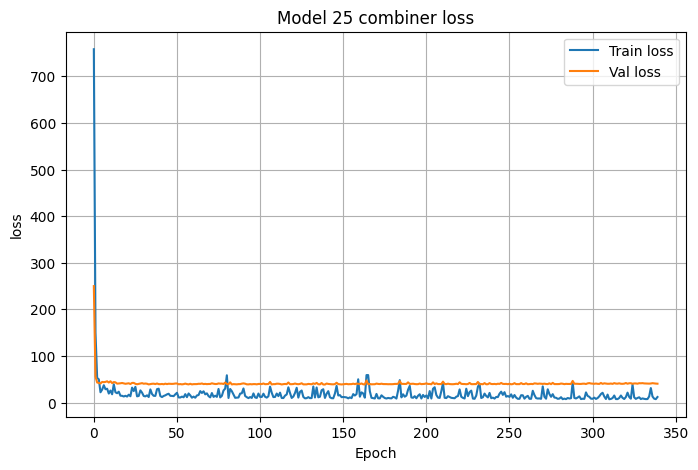

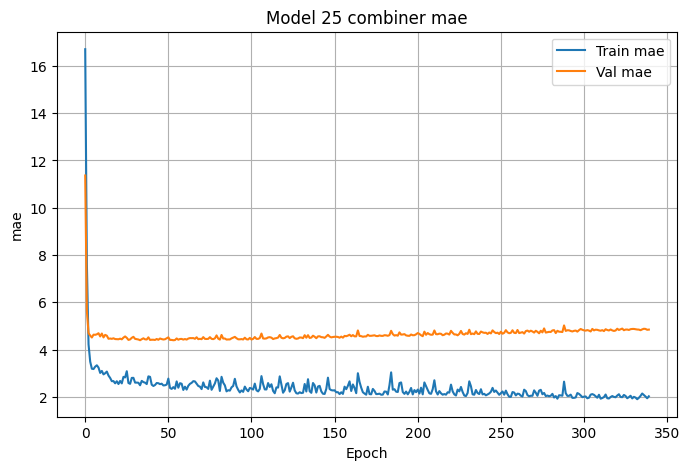

In [ ]:
model25.load_weights(str(model25_best_path))
print("Loaded best Model 25 combiner weights from:", model25_best_path)

for metric in ["loss", "mae"]:
    plt.figure(figsize=(8, 5))
    plt.plot(history_model25.history[metric], label=f"Train {metric}")
    plt.plot(history_model25.history[f"val_{metric}"], label=f"Val {metric}")
    plt.title(f"Model 25 combiner {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()

Prediction model 25

In [ ]:
train_model25_preds = model25.predict(X_train, verbose=1).reshape(-1)
val_model25_preds   = model25.predict(X_val, verbose=1).reshape(-1)
test_model25_preds  = model25.predict(X_test, verbose=1).reshape(-1)

print("Train Model 25 preds:", train_model25_preds.shape)
print("Val Model 25 preds:  ", val_model25_preds.shape)
print("Test Model 25 preds: ", test_model25_preds.shape)

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Train Model 25 preds: (2419,)
Val Model 25 preds:   (334,)
Test Model 25 preds:  (507,)


Metrics and comparrison

In [ ]:
def build_metric_row(model_name, y_train, train_pred, y_val, val_pred, y_test, test_pred):
    train_metrics = compute_metrics(y_train, train_pred)
    val_metrics   = compute_metrics(y_val, val_pred)
    test_metrics  = compute_metrics(y_test, test_pred)

    return {
        "model": model_name,

        "train_mae": train_metrics["mae"],
        "train_mse": train_metrics["mse"],
        "train_rmse": train_metrics["rmse"],
        "train_r2": train_metrics["r2"],
        "train_pmae": train_metrics["pmae"],

        "val_mae": val_metrics["mae"],
        "val_mse": val_metrics["mse"],
        "val_rmse": val_metrics["rmse"],
        "val_r2": val_metrics["r2"],
        "val_pmae": val_metrics["pmae"],

        "test_mae": test_metrics["mae"],
        "test_mse": test_metrics["mse"],
        "test_rmse": test_metrics["rmse"],
        "test_r2": test_metrics["r2"],
        "test_pmae": test_metrics["pmae"],
    }


results = []

results.append(build_metric_row(
    "Model_24_RDINet_RGBD_baseline",
    y_train, train_combiner_df["rdinet_carb_pred"].values,
    y_val,   val_combiner_df["rdinet_carb_pred"].values,
    y_test,  test_combiner_df["rdinet_carb_pred"].values,
))

results.append(build_metric_row(
    "Model_25_RDINet_plus_predicted_mass_simple_combiner",
    y_train, train_model25_preds,
    y_val,   val_model25_preds,
    y_test,  test_model25_preds,
))

results_df = pd.DataFrame(results).sort_values(
    "val_mse",
    ascending=True
).reset_index(drop=True)

display(results_df)

results_csv = MODEL25_DIR / "model25_comparison_rdinet_vs_rdinet_plus_predicted_mass.csv"
results_df.to_csv(results_csv, index=False)

print("Saved results to:", results_csv)

,model,train_mae,train_mse,train_rmse,train_r2,train_pmae,val_mae,val_mse,val_rmse,val_r2,val_pmae,test_mae,test_mse,test_rmse,test_r2,test_pmae
0,Model_25_RDINet_plus_predicted_mass_simple_com...,1.808775,5.855370,2.419787,0.989035,9.316032,4.481817,38.635780,6.215769,0.830366,23.844063,4.948637,55.001999,7.416333,0.818791,25.140921
1,Model_24_RDINet_RGBD_baseline,1.725771,11.469764,3.386704,0.978521,8.888526,4.404018,38.887024,6.235946,0.829263,23.430159,4.719059,53.892159,7.341128,0.822448,23.974581


Saved results to: /content/drive/MyDrive/Speciale/Models/Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion/model25_comparison_rdinet_vs_rdinet_plus_predicted_mass.csv


Saving final combiner model

In [ ]:
final_model_path = MODEL25_DIR / "model25_rdinet_predicted_mass_simple_combiner.keras"
model25.save(final_model_path)

print("Saved final Model 25 combiner to:", final_model_path)

Saved final Model 25 combiner to: /content/drive/MyDrive/Speciale/Models/Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion/model25_rdinet_predicted_mass_simple_combiner.keras


In [ ]:
train_results_df = train_combiner_df.copy()
val_results_df   = val_combiner_df.copy()
test_results_df  = test_combiner_df.copy()

train_results_df["model25_pred"] = train_model25_preds
val_results_df["model25_pred"]   = val_model25_preds
test_results_df["model25_pred"]  = test_model25_preds

for df_out in [train_results_df, val_results_df, test_results_df]:
    df_out["model24_abs_error"] = np.abs(
        df_out["total_carb"].values - df_out["rdinet_carb_pred"].values
    )

    df_out["model25_abs_error"] = np.abs(
        df_out["total_carb"].values - df_out["model25_pred"].values
    )

    df_out["model25_signed_error"] = (
        df_out["model25_pred"].values - df_out["total_carb"].values
    )

train_predictions_csv = MODEL25_DIR / "model25_train_predictions.csv"
val_predictions_csv   = MODEL25_DIR / "model25_val_predictions.csv"
test_predictions_csv  = MODEL25_DIR / "model25_test_predictions.csv"

train_results_df.to_csv(train_predictions_csv, index=False)
val_results_df.to_csv(val_predictions_csv, index=False)
test_results_df.to_csv(test_predictions_csv, index=False)

print("Saved predictions:")
print(train_predictions_csv)
print(val_predictions_csv)
print(test_predictions_csv)

display(test_results_df.head())

Saved predictions:
/content/drive/MyDrive/Speciale/Models/Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion/model25_train_predictions.csv
/content/drive/MyDrive/Speciale/Models/Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion/model25_val_predictions.csv
/content/drive/MyDrive/Speciale/Models/Model_25_RDINet_RGBD_plus_predicted_mass_simple_fusion/model25_test_predictions.csv


,dish_id,total_carb,split,source_cafe,rdinet_carb_pred,predicted_mass,model25_pred,model24_abs_error,model25_abs_error,model25_signed_error
0,dish_1556575327,10.618,test,cafe1,11.217070,157.546173,12.003215,0.599070,1.385215,1.385215
1,dish_1557861216,0.000,test,cafe1,1.343749,23.702986,3.543681,1.343749,3.543681,3.543681
2,dish_1557862345,0.000,test,cafe1,1.691291,47.359634,3.766125,1.691291,3.766125,3.766125
3,dish_1557862696,3.850,test,cafe1,2.287569,67.079849,4.236605,1.562431,0.386605,0.386605
4,dish_1557862738,0.000,test,cafe1,2.843851,98.336594,4.698344,2.843851,4.698344,4.698344


Top 10 best and worst predictions

In [ ]:
best_10 = test_results_df.sort_values(
    "model25_abs_error",
    ascending=True
).head(10)

worst_10 = test_results_df.sort_values(
    "model25_abs_error",
    ascending=False
).head(10)

print("Top 10 best Model 25 predictions:")
display(best_10[[
    "dish_id",
    "total_carb",
    "rdinet_carb_pred",
    "predicted_mass",
    "model25_pred",
    "model25_abs_error",
]])

print("Top 10 worst Model 25 predictions:")
display(worst_10[[
    "dish_id",
    "total_carb",
    "rdinet_carb_pred",
    "predicted_mass",
    "model25_pred",
    "model25_abs_error",
]])

Top 10 best Model 25 predictions:


,dish_id,total_carb,rdinet_carb_pred,predicted_mass,model25_pred,model25_abs_error
307,dish_1563295016,8.182000,7.081125,88.904312,8.178941,0.003059
50,dish_1558376437,3.120000,0.918609,46.886013,3.124390,0.004390
86,dish_1558639787,4.950000,3.099827,78.561447,4.942974,0.007026
172,dish_1560526514,26.031246,25.542202,267.829987,26.044855,0.013609
88,dish_1558639849,5.700000,3.717399,41.809685,5.671156,0.028844
491,dish_1567007814,17.920000,17.636858,171.057693,17.879835,0.040165
173,dish_1560526530,26.787249,26.353920,273.661255,26.746096,0.041153
460,dish_1566587102,8.090585,7.341998,132.332962,8.048940,0.041645
107,dish_1558722171,4.850000,3.040483,70.697952,4.921268,0.071269
299,dish_1563208459,22.543018,22.116543,203.382889,22.456261,0.086758


Top 10 worst Model 25 predictions:


,dish_id,total_carb,rdinet_carb_pred,predicted_mass,model25_pred,model25_abs_error
178,dish_1560801020,61.690983,26.610445,308.626556,27.064924,34.626060
454,dish_1566501594,54.281998,23.460995,463.811127,23.544092,30.737906
424,dish_1565894910,67.945007,38.014194,160.551529,37.435608,30.509399
177,dish_1560800988,61.249092,30.806494,285.817017,30.785395,30.463697
179,dish_1560801041,63.245892,36.962601,349.718689,36.342304,26.903587
326,dish_1563566939,48.869175,22.505318,270.591431,23.180193,25.688982
325,dish_1563566909,46.750000,21.361557,222.541458,21.671963,25.078037
318,dish_1563551220,79.790924,57.230595,546.774780,55.410713,24.380211
327,dish_1563566965,56.243797,32.139458,368.097137,32.026909,24.216888
149,dish_1560367952,45.956913,21.766483,177.674667,22.166048,23.790865
